# Task 2 - Genre Classification

Classifying audio tracks into 114 native Spotify genres presents two main challenges: heavy acoustic overlap across subgeneres and label ambiguity (before deduplication, lots of tracks carried multiple plausible genre tags). 


This notebook investigtes if standard classification is feasible using audio features alone, and evaluates an unsupervised aggregation strategy to define broader macro-genres which are acoustically coherent.

### Workflow

1. **Baseline:** Train a classifier on all **114 native genres** to estabilish a performance benchmark and quantify confusion among predicted (sub)genres.
2. **Acoustic unsupervised clustering:** Cluster audio features with K-Means; pick optimal **K** via silhouette score, creating k macro-genres.
3. **Macro-genre Classification:** Evaluate supervised models on the new genre targets and compare performance against the baseline.

**Models:** LightGBM (baseline), then Logistic Regression, Random Forest, XGBoost, LightGBM, KNN, MLP

**Metrics:** Macro/Weighted F1-score, Confusion Matrix  

**Validation:** Stratified 5-fold CV with randomized hyperparameter search

#### Setup and data splitting

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, f1_score, confusion_matrix
from sklearn.metrics import cohen_kappa_score, classification_report
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


from src import config
from src.data_preprocessor import load_and_clean_data
from src.pipeline import build_preprocessor

RANDOM_STATE = 42

Target is now `track_genre`.

In [2]:
df = load_and_clean_data(str(ROOT / config.DATA_PATH))
print(f"Data shape: {df.shape}")

target = config.TARGET_CLASS
X = df.drop(columns=[target])
y = df[target]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Number of native genres: {y.nunique()}")

Data shape: (81343, 20)
Train shape: (65074, 19), Test shape: (16269, 19)
Number of native genres: 113


#### Stratified K-Fold on train set for cross validation

In [3]:
cv_splits = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X_train, y_train))
print(f"Number of folds: {len(cv_splits)}")

Number of folds: 5


### Baseline: classify all 114 native genres

In [4]:
prep_tree_baseline = build_preprocessor(model_family="tree", task="classification", use_popularity=True)

baseline_pipe = Pipeline([
    ("prep", clone(prep_tree_baseline)),
    ("model", LGBMClassifier(random_state=RANDOM_STATE, n_jobs=1, verbosity=-1))
])

#cross-val
y_pred_baseline_cv = cross_val_predict(baseline_pipe, X_train, y_train, cv=cv_splits, n_jobs=-1)

macro_f1 = f1_score(y_train, y_pred_baseline_cv, average="macro")
weighted_f1 = f1_score(y_train, y_pred_baseline_cv, average="weighted")
print(f"Baseline on all genres - Macro F1: {macro_f1:.3f}, Weighted F1: {weighted_f1:.3f}")

Baseline on all genres - Macro F1: 0.067, Weighted F1: 0.077


The baseline model yields very poor performance.

#### Inspecting most confused genres

In [5]:
# top confusions
labels = sorted(y_train.unique())
cm = confusion_matrix(y_train, y_pred_baseline_cv, labels=labels)
np.fill_diagonal(cm, 0)

pairs = [(labels[i], labels[j], cm[i, j]) for i in range(len(labels)) for j in range(len(labels)) if cm[i, j] > 0]
top_confused = sorted(pairs, key=lambda x: -x[2])[:15]
for a, b, count in top_confused:
    print(f"{a} -> confused with {b}: {count} times")

chicago-house -> confused with detroit-techno: 86 times
grindcore -> confused with black-metal: 70 times
drum-and-bass -> confused with happy: 69 times
detroit-techno -> confused with minimal-techno: 65 times
trance -> confused with deep-house: 64 times
detroit-techno -> confused with chicago-house: 61 times
chicago-house -> confused with minimal-techno: 57 times
chill -> confused with heavy-metal: 57 times
new-age -> confused with idm: 56 times
ambient -> confused with heavy-metal: 55 times
study -> confused with kids: 55 times
classical -> confused with romance: 52 times
honky-tonk -> confused with kids: 52 times
party -> confused with power-pop: 52 times
acoustic -> confused with heavy-metal: 51 times


#### Inspecting the F1-score for each class

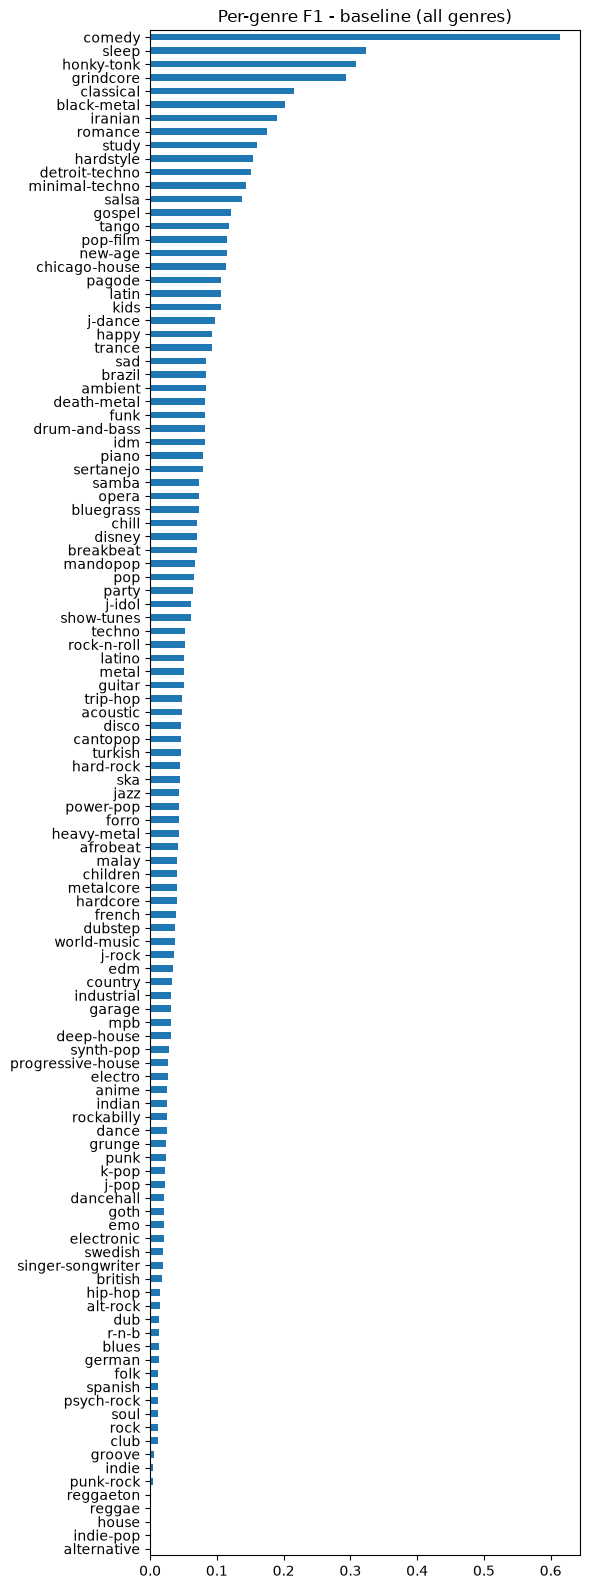

In [6]:
per_class_f1 = pd.Series(f1_score(y_train, y_pred_baseline_cv, average=None, labels=labels), index=labels).sort_values()

fig, ax = plt.subplots(figsize=(6, 16))
per_class_f1.plot(kind="barh", ax=ax)
ax.set_title("Per-genre F1 - baseline (all genres)")
plt.tight_layout(); plt.show()

The model seems to recognize comedy tracks easier.

### Clustering genre-level audio profiles into macro genres

Evaluating best K with silhouette score.

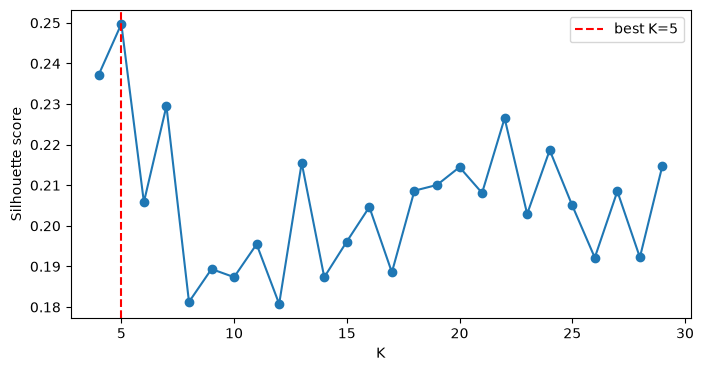

Best K: 5


In [7]:
df_train = df.loc[X_train.index]
genre_profiles = df_train.groupby("track_genre")[config.CONTINUOUS_FEATURES].mean()
scaler = StandardScaler()
genre_profiles_scaled = scaler.fit_transform(genre_profiles)

sil_scores = {}
for k in range(4, 30):
    labels_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(genre_profiles_scaled)
    sil_scores[k] = silhouette_score(genre_profiles_scaled, labels_k)

best_k = max(sil_scores, key=sil_scores.get)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")
ax.axvline(best_k, color="r", linestyle="--", label=f"best K={best_k}")
ax.set_xlabel("K"); ax.set_ylabel("Silhouette score"); ax.legend()
plt.show()
print(f"Best K: {best_k}")

Another approach to evaluate the best K: silhouette score alone doesn't guarantee balanced clusters. So we compare K=5...13 on three different criteria -> silhouette score, cluster imbalance and downstream classification F1, to check if a higher K produces a more useful macro-genre split.

In [8]:
# candidates for k
candidate_ks = [5, 6, 7, 8, 10, 13]
k_comparison = []

for k in candidate_ks:
    labels_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(genre_profiles_scaled)
    mapping_k = dict(zip(genre_profiles.index, labels_k))
    y_train_k = y_train.map(mapping_k)

    cluster_sizes = y_train_k.value_counts()
    imbalance = cluster_sizes.max() / cluster_sizes.min()

    q_pipe = Pipeline([
        ("prep", clone(build_preprocessor(model_family="tree", task="classification", use_popularity=True))),
        ("model", RandomForestClassifier(n_estimators=150, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1))
    ])
    y_pred_k = cross_val_predict(q_pipe, X_train, y_train_k, cv=cv_splits, n_jobs=-1)

    k_comparison.append({
        "k": k,
        "silhouette": sil_scores.get(k, silhouette_score(genre_profiles_scaled, labels_k)),
        "imbalance_ratio": imbalance,
        "f1_macro": f1_score(y_train_k, y_pred_k, average="macro")
    })

pd.DataFrame(k_comparison)

,k,silhouette,imbalance_ratio,f1_macro
0,5,0.249730,40.415190,0.769692
1,6,0.205826,25.708861,0.726368
2,7,0.229509,29.216456,0.695173
3,8,0.181254,19.796203,0.658435
4,10,0.187362,18.255291,0.684424
5,13,0.215498,19.582011,0.645231


Confirming K=5 as the final decision.

#### Inspecting and mapping the new macro-genres 
Mapping genre -> macro-genre, applyed to train and test

In [9]:
k_means_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
macro_labels = k_means_final.fit_predict(genre_profiles_scaled)
genre_to_macro = dict(zip(genre_profiles.index, macro_labels))

mapping_df = pd.DataFrame({"genre": genre_profiles.index, "macro_genre": macro_labels})
for macro_id,  group in mapping_df.groupby("macro_genre"):
    print(f"Macro-genre {macro_id}: {group['genre'].tolist()}")

y_train_macro = y_train.map(genre_to_macro)
y_test_macro = y_test.map(genre_to_macro)
assert y_train_macro.isna().sum() == 0 and y_test_macro.isna().sum() == 0

Macro-genre 0: ['alt-rock', 'black-metal', 'club', 'death-metal', 'drum-and-bass', 'dub', 'dubstep', 'forro', 'garage', 'gospel', 'goth', 'grindcore', 'groove', 'grunge', 'happy', 'hard-rock', 'hardcore', 'hardstyle', 'heavy-metal', 'industrial', 'j-idol', 'j-rock', 'metal', 'metalcore', 'pagode', 'party', 'power-pop', 'progressive-house', 'punk', 'punk-rock', 'sertanejo', 'ska', 'world-music']
Macro-genre 1: ['ambient', 'classical', 'disney', 'guitar', 'iranian', 'jazz', 'new-age', 'opera', 'piano', 'romance', 'sleep', 'study']
Macro-genre 2: ['acoustic', 'afrobeat', 'alternative', 'anime', 'bluegrass', 'blues', 'brazil', 'british', 'cantopop', 'children', 'chill', 'country', 'dance', 'dancehall', 'deep-house', 'disco', 'edm', 'electro', 'electronic', 'emo', 'folk', 'french', 'funk', 'german', 'hip-hop', 'honky-tonk', 'house', 'indian', 'indie', 'indie-pop', 'j-dance', 'j-pop', 'k-pop', 'kids', 'latin', 'latino', 'malay', 'mandopop', 'mpb', 'pop', 'pop-film', 'psych-rock', 'r-n-b', 'r

In [10]:
cluster_size = mapping_df['macro_genre'].value_counts().sort_index()
print(cluster_size)

macro_genre
0    33
1    12
2    60
3     7
4     1
Name: count, dtype: int64


In [11]:
imbalance_ratio = cluster_size.max() / cluster_size.min()
print(f"k={best_k} - imbalance ratio(max/min cluster size): {imbalance_ratio:.1f}")

k=5 - imbalance ratio(max/min cluster size): 60.0


The macro-genres are a bit unbalanced, but K=5 was the best validated choice (increasing K will lead to worse F1).

There is a musical coherence within the 5 new categories.

K=5 is confirmed to be still the best value for k, having the best silhouette, f1_macro and imbalance_ratio.

In [13]:
import joblib
joblib.dump(genre_to_macro, ROOT / "notebooks" / "genre_to_macro.pkl")

['C:\\Users\\angel\\Documents\\spotify_clean\\notebooks\\genre_to_macro.pkl']

### Macro-genres classification

Exploring a set of different models with a standard configuration to choose the best ones to tune.

In [14]:
prep_tree_macro = build_preprocessor(model_family="tree", task="classification", use_popularity=True)
prep_linear_macro = build_preprocessor(model_family="linear", task="classification", use_popularity=True)

candidates_macro = {
    "Logistic Regression": Pipeline([("prep", clone(prep_linear_macro)), ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "Random Forest": Pipeline([("prep", clone(prep_tree_macro)), ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1, class_weight="balanced"))]),
    "XGBoost": Pipeline([("prep", clone(prep_tree_macro)), ("model", XGBClassifier(random_state=RANDOM_STATE, n_jobs=1))]),
    "LightGBM": Pipeline([("prep", clone(prep_tree_macro)), ("model", LGBMClassifier(random_state=RANDOM_STATE, n_jobs=1, verbosity=-1, class_weight="balanced"))]),
    "MLP": Pipeline([("prep", clone(prep_linear_macro)), ("model", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, early_stopping=True, random_state=RANDOM_STATE))]),
    "KNN": Pipeline([("prep", clone(prep_linear_macro)), ("model", KNeighborsClassifier(n_neighbors=15, n_jobs=1))])
}

cv_splits_macro = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X_train, y_train_macro))

results_macro = []
for name, pipe in candidates_macro.items():
    scores = cross_validate(pipe, X_train, y_train_macro, cv=cv_splits_macro,
                            scoring=["f1_macro", "f1_weighted"], n_jobs=-1)
    results_macro.append({"model": name, "f1_macro": scores["test_f1_macro"].mean()})
pd.DataFrame(results_macro).sort_values("f1_macro", ascending=False)

,model,f1_macro
2,XGBoost,0.786182
1,Random Forest,0.777792
4,MLP,0.759146
3,LightGBM,0.754274
5,KNN,0.734867
0,Logistic Regression,0.591086


#### Hyperparameters tuning

Tuning the top3(+1) models that achieved the best f1-score.

In [15]:
top_candidates = ["XGBoost", "Random Forest", "MLP", "LightGBM"]

param_distributions = {
    "XGBoost": {
        "model__n_estimators":[200, 400, 600],
        "model__max_depth": [4, 6, 8, 10],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.7, 0.85, 1.0],
    },
    "Random Forest": {
        "model__n_estimators":[300, 500, 700],
        "model__max_depth": [15, 20, 30, None],
        "model__min_samples_leaf": [1, 2, 5],
        "model__max_features": ["sqrt", "log2", 1.0],
    },
    "MLP": {
        "model__hidden_layer_sizes":[(64,), (64, 32), (128, 64)],
        "model__alpha": np.logspace(-4, -1, 8),
        "model__learning_rate_init": [0.001, 0.005, 0.01],
    },
    "LightGBM": {
        "model__n_estimators":[300, 500, 700],
        "model__num_leaves": [15, 31, 63],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.7, 0.85, 1.0],
    }
}

n_iter_by_model = {
    "XGBoost": 20,
    "Random Forest": 20,
    "MLP": 15,
    "LightGBM": 20,
}

tuned_results_macro = {}
for name in top_candidates:
    search = RandomizedSearchCV(
        candidates_macro[name], param_distributions[name],
        n_iter=n_iter_by_model[name],
        cv=cv_splits_macro,
        scoring="f1_macro",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    search.fit(X_train, y_train_macro)
    tuned_results_macro[name] = search
    print(f"{name}: best F1 macro = {search.best_score_:.3f}, best_params = {search.best_params_}")


XGBoost: best F1 macro = 0.795, best_params = {'model__subsample': 1.0, 'model__n_estimators': 600, 'model__max_depth': 10, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.85}
Random Forest: best F1 macro = 0.779, best_params = {'model__n_estimators': 300, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}
MLP: best F1 macro = 0.768, best_params = {'model__learning_rate_init': 0.01, 'model__hidden_layer_sizes': (128, 64), 'model__alpha': np.float64(0.03727593720314938)}
LightGBM: best F1 macro = 0.792, best_params = {'model__subsample': 0.85, 'model__num_leaves': 63, 'model__n_estimators': 500, 'model__learning_rate': 0.1}


#### Final model
XGboost classifier is chosen because of best performances among the others.

In [16]:
best_name = max(tuned_results_macro, key=lambda n: tuned_results_macro[n].best_score_)
best_model_macro = tuned_results_macro[best_name].best_estimator_

print(f"Final model: {best_name}")
print(f"Best params: {tuned_results_macro[best_name].best_params_}")
print(f"F1 macro (CV): {tuned_results_macro[best_name].best_score_:.3f}")

Final model: XGBoost
Best params: {'model__subsample': 1.0, 'model__n_estimators': 600, 'model__max_depth': 10, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.85}
F1 macro (CV): 0.795


#### Final CV prediction

In [17]:
y_pred_final_cv = cross_val_predict(best_model_macro, X_train, y_train_macro, cv=cv_splits_macro, n_jobs=-1)
kappa_final = cohen_kappa_score(y_train_macro, y_pred_final_cv)
print(f"Cohen's Kappa (tuned {best_name}, CV): {kappa_final:.3f}")
print(classification_report(y_train_macro, y_pred_final_cv))

Cohen's Kappa (tuned XGBoost, CV): 0.656
              precision    recall  f1-score   support

           0       0.77      0.70      0.74     19794
           1       0.83      0.72      0.77      7948
           2       0.77      0.86      0.81     31928
           3       0.83      0.71      0.77      4614
           4       0.98      0.82      0.89       790

    accuracy                           0.78     65074
   macro avg       0.84      0.76      0.79     65074
weighted avg       0.79      0.78      0.78     65074



**Cohen's Kappa** -> agreement between predicted and true labels while correcting for the agreement expected by pure chance. Robust against imbalanced class distributions, used here to provide context alongside Macro-F1.

#### FINAL EVALUATION ON TEST SET

In [18]:
final_model_macro = clone(best_model_macro)
final_model_macro.fit(X_train, y_train_macro)

y_pred_test_macro = final_model_macro.predict(X_test)

print("=== TEST SET - FINAL EVALUATION ===")
print(f"F1 macro: {f1_score(y_test_macro, y_pred_test_macro, average='macro'):.3f}")
print(f"F1 weighted: {f1_score(y_test_macro, y_pred_test_macro, average='weighted'):.3f}")
print(f"Cohen's Kappa: {cohen_kappa_score(y_test_macro, y_pred_test_macro):.3f}")
print(classification_report(y_test_macro, y_pred_test_macro))

=== TEST SET - FINAL EVALUATION ===
F1 macro: 0.797
F1 weighted: 0.784
Cohen's Kappa: 0.661
              precision    recall  f1-score   support

           0       0.77      0.70      0.74      4950
           1       0.84      0.73      0.78      1986
           2       0.78      0.86      0.82      7983
           3       0.81      0.71      0.75      1153
           4       0.98      0.82      0.90       197

    accuracy                           0.79     16269
   macro avg       0.83      0.77      0.80     16269
weighted avg       0.79      0.79      0.78     16269



#### Feature importance

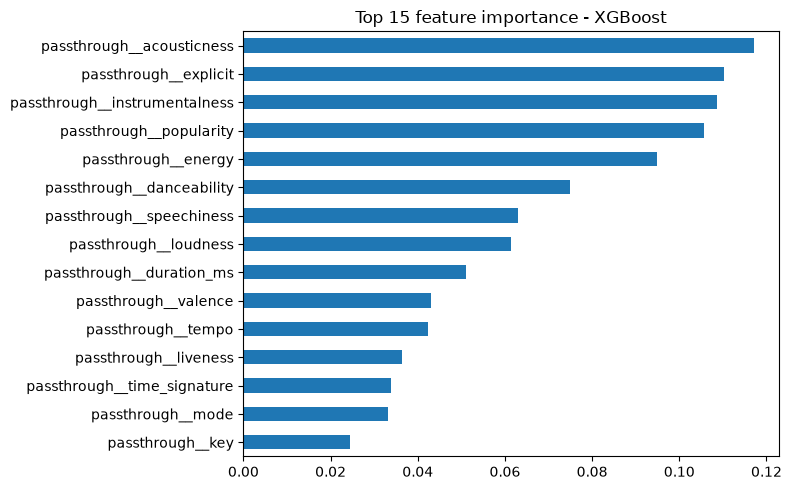

In [19]:
importances = final_model_macro.named_steps["model"].feature_importances_
feat_names = final_model_macro.named_steps["prep"].get_feature_names_out()
imp_df = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8,5))
imp_df.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title(f"Top 15 feature importance - {best_name}")
plt.tight_layout(); plt.show()

#### Confusion Matrix

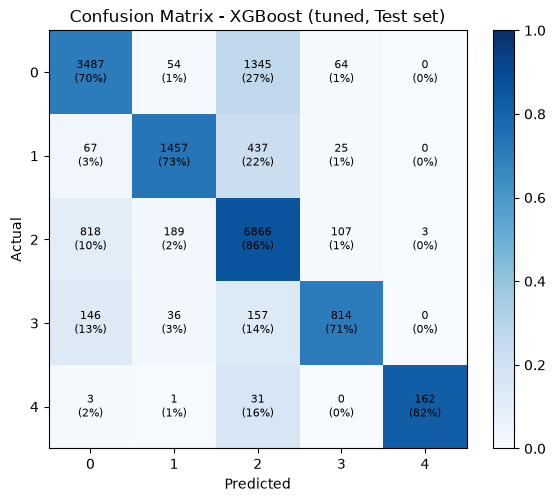

In [20]:
cm = confusion_matrix(y_test_macro, y_pred_test_macro)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]}\n({cm_norm[i, j]:.0%})", ha="center", va="center", fontsize=8)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix - {best_name} (tuned, Test set)")
plt.colorbar(im)
plt.tight_layout(); plt.show()

**Error Analysis**

The confusion matrix above shows strong recall scores across the diagonal, ranging from 70% (Cluster 0) to 86% (Cluster 2).

Classification errors are more predominant in Cluster 2, which also attracts a lot of predictions from other clusters:
* **Overlap with Cluster 0**: The most evident misclassification occurs with Cluster 0, where 27% of the instances (1345 tracks) are assigned to cluster 2, alongside a reciprocal leakage (10% of Cluster 2 predicted as Cluster 0). This highlights a subtle difference between high-energy subgeneres whose acoustic features heavily overlap.
* **Other infiltrations**: Cluster 1, 3 and 4 also show some misclassifications with Cluster 2 (22%, 14% and 16% respectively). This may be motivated by the prevalence of Cluster 2 in the test split, which slightly biases decision boundaries toward the majority class in ambiguous acoustic regions.
* **Cluster 4 Isolation**: In contrast this Cluster has a distinct separation despite its smaller volume, with near zero false positives and high precision. This can be explained as Cluster 4 consists only of one genre with a very distinct acoustic profile.

This pattern confirms that errors are primarily due to the intrinsic acoustic variance of genre centroids rather than model underfitting.

#### Final results
Comparing the results on both classification stages.

In [24]:
summary = pd.DataFrame([
    {"stage": "Baseline(114 native genres)", "f1_macro": macro_f1, "kappa": cohen_kappa_score(y_train, y_pred_baseline_cv)},
    {"stage": f"Macro-genre (K=5, {best_name} tuned) - Test",
     "f1_macro": f1_score(y_test_macro, y_pred_test_macro, average="macro"),
     "kappa": cohen_kappa_score(y_test_macro, y_pred_test_macro)},
])
summary

,stage,f1_macro,kappa
0,Baseline(114 native genres),0.067478,0.066711
1,"Macro-genre (K=5, XGBoost tuned) - Test",0.796640,0.660926


The final comparative results clearrly show the impact of the genre aggregation strategy:
* **Baseline Limitation**: Attempting direct multi-class classification across the 114 native genres yields near zero predictive power (Macro-F1 of ~0.067). Give the extreme acoustic overlap and sematic fragmentation, models trained on rwa subgeneres struggle to separate adjacent categories using audio features alone.
* **Macor-Genre Generalization**: Mapping the subgeneres into 5 unsupervised macro-clusters increases performance significantly, reaching a **Macro-F1 of 0.797** and a **Kappa of 0.0661** on the unsees test split with a tuned XGBoost classifier.

Aggregating subgeneres represents a necessary trade-off: while it heavily boost predictions performance, it may force peripherical tracks into neighboring clustes more aligned to their individual audio profile rather than thier assigned centroid.